<a href="https://colab.research.google.com/github/diomani-ouattara/Portfolio-Data-scientist/blob/main/talent_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Talent Sourcing ML Pipeline
**Role:** Aspiring / Seeking Human Resources

**Pipeline overview:**
```
Raw candidates
     |
Feature Engineering  <-- job_title (TF-IDF), connections (log-norm), keyword boost
     |
Initial Ranking      <-- weighted cosine similarity to query
     |
Reviewer Stars       <-- supervisory signal (positive anchor)
     |
Re-Ranking (LTR)     <-- blend original score + similarity to starred ideal
     |
Filtering & Cut-off  <-- remove noise, find role-agnostic threshold
```

## 0 - Setup & Data Upload

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from google.colab import files
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries ready')

Libraries ready


In [3]:
# Option A: file already present (e.g. uploaded to Colab session storage)
#FILE_PATH = 'potential-talents.xlsx'

# Option B: upload interactively in Colab - uncomment both lines:
 #from google.colab import files
 #FILE_PATH = list(files.upload().keys())[0]
 # Upload file

print("Please upload your Talent file:")
uploaded = files.upload()

# Get filename
filename = list(uploaded.keys())[0]
#df = pd.read_csv(filename)

df_raw = pd.read_excel(filename)
print(f'Loaded {len(df_raw)} candidates, columns: {df_raw.columns.tolist()}')
df_raw.head()

Please upload your Talent file:


Saving potential-talents.xlsx to potential-talents.xlsx
Loaded 104 candidates, columns: ['id', 'job_title', 'location', 'connection', 'fit']


,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


## 1 - Exploratory Data Analysis

In [4]:
print('Shape:', df_raw.shape)
print('\nDtypes:\n', df_raw.dtypes)
print('\nNulls:\n', df_raw.isnull().sum())
print('\nConnection value counts:\n', df_raw['connection'].value_counts().to_string())

Shape: (104, 5)

Dtypes:
 id              int64
job_title      object
location       object
connection     object
fit           float64
dtype: object

Nulls:
 id              0
job_title       0
location        0
connection      0
fit           104
dtype: int64

Connection value counts:
 connection
500+     44
85        7
61        7
44        6
1         5
2         4
390       2
57        2
7         2
4         2
82        1
16        1
5         1
409       1
52        1
455       1
212       1
174       1
268       1
50        1
40        1
18        1
349       1
155       1
39        1
64        1
9         1
415       1
19        1
71        1
48        1
103       1
49        1


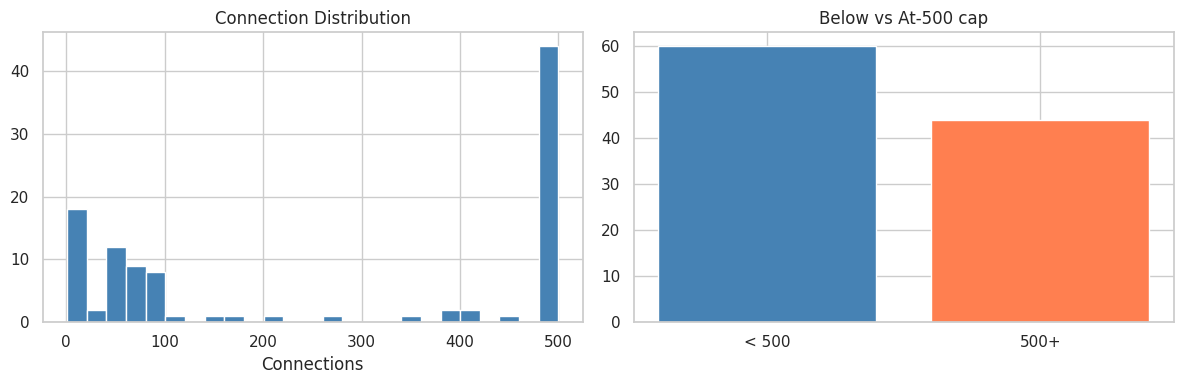

44 candidates have 500+ connections (42.3%)


In [5]:
def parse_conn(v):
    return 500 if str(v).strip() == '500+' else int(v)

conn_vals = df_raw['connection'].apply(parse_conn)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(conn_vals, bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Connection Distribution'); axes[0].set_xlabel('Connections')
axes[1].bar(['< 500', '500+'], [(conn_vals < 500).sum(), (conn_vals >= 500).sum()],
            color=['steelblue', 'coral'])
axes[1].set_title('Below vs At-500 cap')
plt.tight_layout(); plt.show()
print(f'{(conn_vals >= 500).sum()} candidates have 500+ connections ({(conn_vals>=500).mean()*100:.1f}%)')

In [6]:
print('Sample job titles:')
for t in df_raw['job_title'].sample(15, random_state=42):
    print(' -', t)

Sample job titles:
 - 2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional
 - Experienced Retail Manager and aspiring Human Resources Professional
 - Human Resources Coordinator at InterContinental Buckhead Atlanta
 - Student at Chapman University
 - Aspiring Human Resources Professional
 - Seeking Human  Resources Opportunities. Open to travel and relocation.
 - Seeking employment opportunities within Customer Service or Patient Care
 - Advisory Board Member at Celal Bayar University
 - Student at Chapman University
 - 2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional
 - 2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional
 - Native English Teacher at EPIK (English Program in Korea)
 - Director Human Resources  at EY
 - Student at Indiana University Kokomo - Business Management - 
Retail Manager at Delphi Hardware and Paint
 - H

## 2 - Feature Engineering

In [7]:
# ---- Change query keywords here for a different role ----
QUERIES = ['aspiring human resources', 'seeking human resources']
QUERY_STR = ' '.join(QUERIES)
# ---------------------------------------------------------

df = df_raw.copy()

# Feature 1: Normalized connections (log scale, 0-1)
df['conn_num']   = df['connection'].apply(parse_conn)
df['conn_score'] = np.log1p(df['conn_num']) / np.log1p(500)

# Feature 2: TF-IDF cosine similarity to role query
all_texts = df['job_title'].tolist() + [QUERY_STR]
vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', sublinear_tf=True)
tfidf_matrix = vectorizer.fit_transform(all_texts)
candidate_vecs       = tfidf_matrix[:-1]
query_vec            = tfidf_matrix[-1]
candidate_vecs_dense = candidate_vecs.toarray()

cosine_scores      = cosine_similarity(query_vec, candidate_vecs).flatten()
df['cosine_score'] = cosine_scores

# Feature 3: Keyword boost for exact HR / aspiring signals
HR_TERMS     = ['human resources', ' hr ', 'hris', 'hrm', 'talent', 'recruiting', 'staffing', 'people development']
ASPIRE_TERMS = ['aspiring', 'seeking', 'looking for', 'entry level', 'intern']

def keyword_boost(title):
    t = title.lower()
    return 0.15 * any(k in t for k in HR_TERMS) + 0.10 * any(k in t for k in ASPIRE_TERMS)

df['kw_boost'] = df['job_title'].apply(keyword_boost)

print('Features computed:')
print(df[['id','cosine_score','conn_score','kw_boost']].describe().round(3))

Features computed:
            id  cosine_score  conn_score  kw_boost
count  104.000       104.000     104.000   104.000
mean    52.500         0.146       0.759     0.140
std     30.166         0.153       0.281     0.109
min      1.000         0.000       0.111     0.000
25%     26.750         0.000       0.623     0.000
50%     52.500         0.120       0.847     0.150
75%     78.250         0.235       1.000     0.250
max    104.000         0.462       1.000     0.250


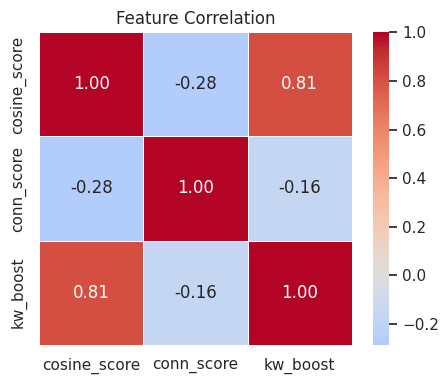

In [8]:
feat_cols = ['cosine_score', 'conn_score', 'kw_boost']
corr = df[feat_cols].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation'); plt.tight_layout(); plt.show()

## 3 - Initial Ranking

In [9]:
# Tunable weights
W_COSINE, W_CONN, W_KW = 0.70, 0.20, 0.10

raw_fit = W_COSINE * df['cosine_score'] + W_CONN * df['conn_score'] + W_KW * df['kw_boost']
df['fit'] = (raw_fit - raw_fit.min()) / (raw_fit.max() - raw_fit.min())

df = df.sort_values('fit', ascending=False).reset_index(drop=True)
df['rank'] = df.index + 1

# Map candidate id to its row index in candidate_vecs_dense (original file order)
id_to_vec_idx = {int(row['id']): i
                 for i, row in df.sort_values('id').reset_index(drop=True).iterrows()}
df['vec_idx'] = df['id'].apply(lambda x: id_to_vec_idx[int(x)])

print('Top 20:')
display(df[['rank','id','job_title','connection','fit']]
        .head(20).style.format({'fit': '{:.4f}'})
        .background_gradient(subset=['fit'], cmap='YlGn'))

Top 20:


,rank,id,job_title,connection,fit
0,1,28,Seeking Human Resources Opportunities,390,1.0000
1,2,30,Seeking Human Resources Opportunities,390,1.0000
2,3,97,Aspiring Human Resources Professional,71,0.8608
3,4,99,Seeking Human Resources Position,48,0.8456
4,5,62,Seeking Human Resources HRIS and Generalist Positions,500+,0.8362
5,6,53,Seeking Human Resources HRIS and Generalist Positions,500+,0.8362
6,7,40,Seeking Human Resources HRIS and Generalist Positions,500+,0.8362
7,8,10,Seeking Human Resources HRIS and Generalist Positions,500+,0.8362
8,9,3,Aspiring Human Resources Professional,44,0.8309
9,10,21,Aspiring Human Resources Professional,44,0.8309


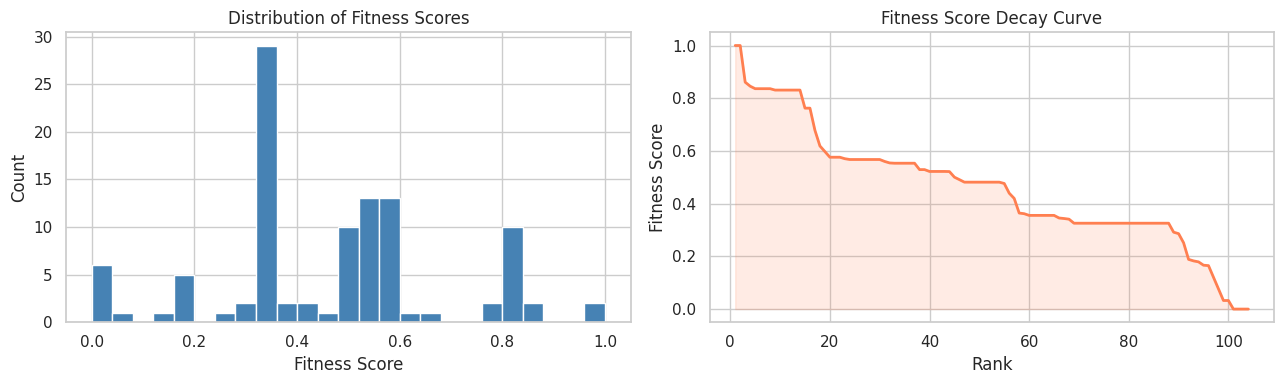

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['fit'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Fitness Score'); axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Fitness Scores')
axes[1].plot(df['rank'], df['fit'], color='coral', linewidth=2)
axes[1].fill_between(df['rank'], df['fit'], alpha=0.15, color='coral')
axes[1].set_xlabel('Rank'); axes[1].set_ylabel('Fitness Score')
axes[1].set_title('Fitness Score Decay Curve')
plt.tight_layout(); plt.show()

## 4 - Re-Ranking on Starring

When a recruiter stars a candidate, that candidate becomes a **positive anchor**.
The re-ranking formula is:

    new_score = alpha * original_fit + beta * sim(candidate, starred_ideal)

- alpha = 0.55 (weight on original relevance)
- beta  = 0.45 (weight on similarity to starred ideal)
- Multiple starred candidates: their TF-IDF vectors are averaged into a composite ideal
- Each new starring automatically triggers a full re-rank

In [11]:
def rerank(df, candidate_vecs_dense, id_to_vec_idx, starred_ids, alpha=0.55, beta=0.45):
    """
    Re-rank using starred candidates as positive anchors.
    starred_ids : list of candidate ids that have been starred
    """
    starred_idxs = [id_to_vec_idx[int(s)] for s in starred_ids]
    ideal_vec    = candidate_vecs_dense[starred_idxs].mean(axis=0, keepdims=True)
    raw_sims     = cosine_similarity(ideal_vec, candidate_vecs_dense).flatten()

    df2 = df.copy()
    df2['sim_to_ideal'] = df2['id'].apply(lambda x: raw_sims[id_to_vec_idx[int(x)]])
    s_min, s_max = df2['sim_to_ideal'].min(), df2['sim_to_ideal'].max()
    df2['sim_norm']     = (df2['sim_to_ideal'] - s_min) / (s_max - s_min + 1e-9)
    df2['reranked_fit'] = alpha * df2['fit'] + beta * df2['sim_norm']
    df2 = df2.sort_values('reranked_fit', ascending=False).reset_index(drop=True)
    df2['new_rank'] = df2.index + 1
    return df2

print('rerank() defined')

rerank() defined


In [12]:
# Simulation 1: Star the candidate at rank 7
STARRED_ID_1 = int(df[df['rank'] == 7]['id'].values[0])
print(f'Starring rank-7 (id={STARRED_ID_1}):')
print(' ', df[df['id'] == STARRED_ID_1]['job_title'].values[0])

r1 = rerank(df, candidate_vecs_dense, id_to_vec_idx, [STARRED_ID_1])

print('\nTop 15 after starring rank-7:')
display(r1[['new_rank','id','job_title','connection','fit','reranked_fit']]
        .head(15).style
        .format({'fit': '{:.4f}', 'reranked_fit': '{:.4f}'})
        .background_gradient(subset=['reranked_fit'], cmap='YlGn'))

Starring rank-7 (id=40):
  Seeking Human Resources HRIS and Generalist Positions

Top 15 after starring rank-7:


,new_rank,id,job_title,connection,fit,reranked_fit
0,1,10,Seeking Human Resources HRIS and Generalist Positions,500+,0.8362,0.9099
1,2,40,Seeking Human Resources HRIS and Generalist Positions,500+,0.8362,0.9099
2,3,53,Seeking Human Resources HRIS and Generalist Positions,500+,0.8362,0.9099
3,4,62,Seeking Human Resources HRIS and Generalist Positions,500+,0.8362,0.9099
4,5,30,Seeking Human Resources Opportunities,390,1.0000,0.6874
5,6,28,Seeking Human Resources Opportunities,390,1.0000,0.6874
6,7,99,Seeking Human Resources Position,48,0.8456,0.5978
7,8,97,Aspiring Human Resources Professional,71,0.8608,0.5268
8,9,3,Aspiring Human Resources Professional,44,0.8309,0.5104
9,10,21,Aspiring Human Resources Professional,44,0.8309,0.5104


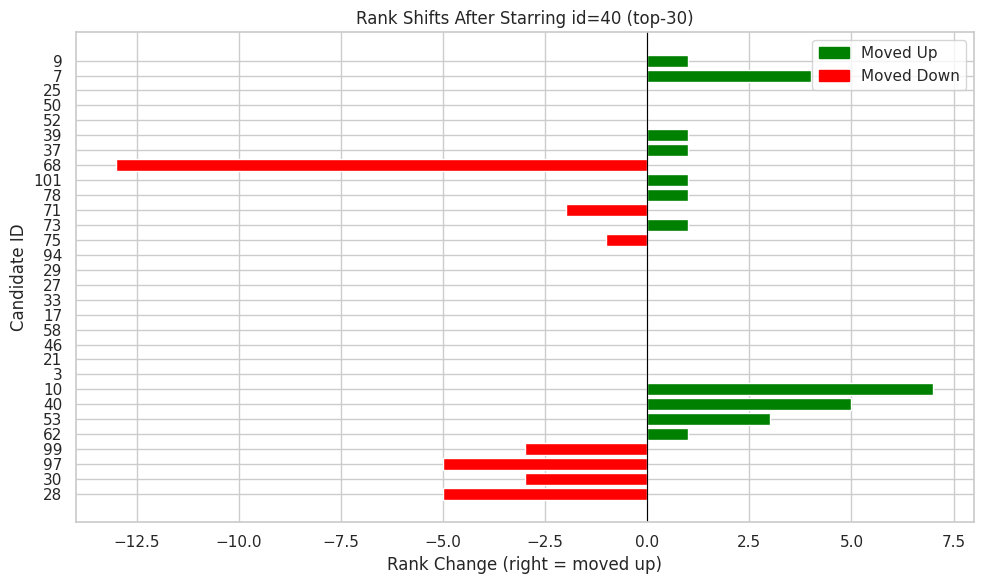

In [13]:
# Visualise rank shifts for top-30 candidates
top30_ids = df[df['rank'] <= 30]['id'].tolist()
old_ranks = {int(r['id']): int(r['rank'])     for _, r in df.iterrows()}
new_ranks = {int(r['id']): int(r['new_rank']) for _, r in r1.iterrows()}

shifts_df = pd.DataFrame(
    [(cid, old_ranks[cid], new_ranks[cid], new_ranks[cid] - old_ranks[cid]) for cid in top30_ids],
    columns=['id', 'old_rank', 'new_rank', 'delta']
).sort_values('old_rank')

colors = ['green' if d < 0 else ('red' if d > 0 else 'gray') for d in shifts_df['delta']]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(shifts_df['id'].astype(str), -shifts_df['delta'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Rank Change (right = moved up)')
ax.set_ylabel('Candidate ID')
ax.set_title(f'Rank Shifts After Starring id={STARRED_ID_1} (top-30)')
ax.legend(handles=[mpatches.Patch(color='green', label='Moved Up'),
                   mpatches.Patch(color='red',   label='Moved Down')])
plt.tight_layout(); plt.show()

In [14]:
# Simulation 2: Additionally star rank-18 (composite ideal)
STARRED_ID_2 = int(df[df['rank'] == 18]['id'].values[0])
print(f'Additionally starring rank-18 (id={STARRED_ID_2}):')
print(' ', df[df['id'] == STARRED_ID_2]['job_title'].values[0])

r2 = rerank(df, candidate_vecs_dense, id_to_vec_idx, [STARRED_ID_1, STARRED_ID_2])

print('\nTop 15 after 2nd starring:')
display(r2[['new_rank','id','job_title','connection','reranked_fit']]
        .head(15).style
        .format({'reranked_fit': '{:.4f}'})
        .background_gradient(subset=['reranked_fit'], cmap='YlGn'))

Additionally starring rank-18 (id=75):
  Nortia Staffing is seeking Human Resources, Payroll & Administrative Professionals!!  (408) 709-2621

Top 15 after 2nd starring:


,new_rank,id,job_title,connection,reranked_fit
0,1,10,Seeking Human Resources HRIS and Generalist Positions,500+,0.9099
1,2,40,Seeking Human Resources HRIS and Generalist Positions,500+,0.9099
2,3,53,Seeking Human Resources HRIS and Generalist Positions,500+,0.9099
3,4,62,Seeking Human Resources HRIS and Generalist Positions,500+,0.9099
4,5,75,"Nortia Staffing is seeking Human Resources, Payroll & Administrative Professionals!! (408) 709-2621",500+,0.7904
5,6,30,Seeking Human Resources Opportunities,390,0.7382
6,7,28,Seeking Human Resources Opportunities,390,0.7382
7,8,99,Seeking Human Resources Position,48,0.6468
8,9,97,Aspiring Human Resources Professional,71,0.5466
9,10,3,Aspiring Human Resources Professional,44,0.5301


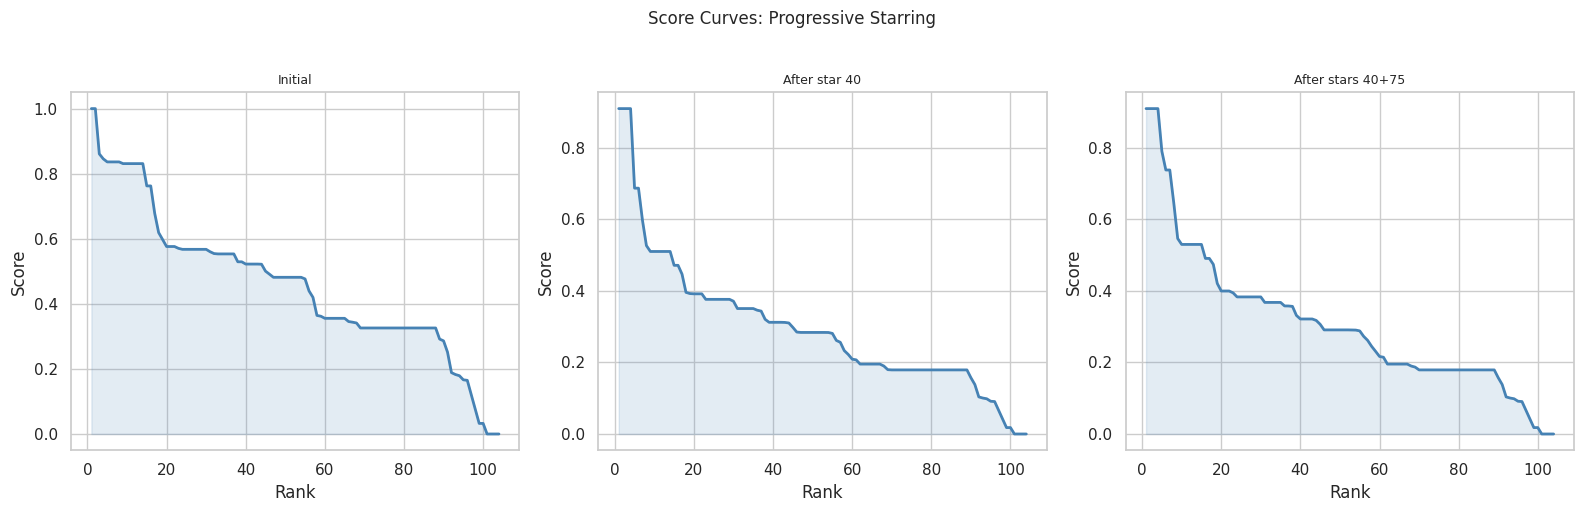

In [15]:
# Progressive score curves with each starring action
stages = [
    ('Initial',                      df.set_index('id')['fit']),
    (f'After star {STARRED_ID_1}',   r1.set_index('id')['reranked_fit']),
    (f'After stars {STARRED_ID_1}+{STARRED_ID_2}', r2.set_index('id')['reranked_fit']),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (label, scores) in zip(axes, stages):
    ranked = scores.sort_values(ascending=False).values
    ax.plot(range(1, len(ranked)+1), ranked, color='steelblue', linewidth=2)
    ax.fill_between(range(1, len(ranked)+1), ranked, alpha=0.15, color='steelblue')
    ax.set_title(label, fontsize=9); ax.set_xlabel('Rank'); ax.set_ylabel('Score')
plt.suptitle('Score Curves: Progressive Starring', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## 5 - Filtering: Who Should Not Be in the List?

In [16]:
# Hard filter: cosine_score == 0 means zero vocabulary overlap with the role query
hard_mask = df['cosine_score'] == 0
print(f'Hard filter removes {hard_mask.sum()} candidates with zero query overlap:')
print(df[hard_mask][['id','job_title','connection']].to_string(index=False))

Hard filter removes 42 candidates with zero query overlap:
 id                                                                                                   job_title connection
 59                                                                      People Development Coordinator at Ryan      500+ 
 47                                                                      People Development Coordinator at Ryan      500+ 
 34                                                                      People Development Coordinator at Ryan      500+ 
 18                                                                      People Development Coordinator at Ryan      500+ 
 22                                                                      People Development Coordinator at Ryan      500+ 
  4                                                                      People Development Coordinator at Ryan      500+ 
 85                                          RRP Brand Portfolio Executive at JT

In [17]:
# Soft filter: bottom 25% by fitness score
SOFT_THRESHOLD = df['fit'].quantile(0.25)
soft_mask = df['fit'] < SOFT_THRESHOLD
print(f'Soft filter (fit < {SOFT_THRESHOLD:.4f}) removes {soft_mask.sum()} candidates')
print(df[soft_mask][['rank','id','job_title','connection','fit']].head(15).to_string(index=False))

Soft filter (fit < 0.3258) removes 16 candidates
 rank  id                                                                                                  job_title connection      fit
   89  92                                   Seeking employment opportunities within Customer Service or Patient Care         64 0.291715
   90  83                                                                  HR Manager at Endemol Shine North America        268 0.286201
   91  90                                                         Undergraduate Research Assistant at Styczynski Lab        155 0.251518
   92  95                                                                      Student at Westfield State University         57 0.188536
   93  80                                                                   Junior MES Engineer| Information Systems         52 0.182798
   94 102                                                           Business Intelligence and Analytics at Travelers         49 0

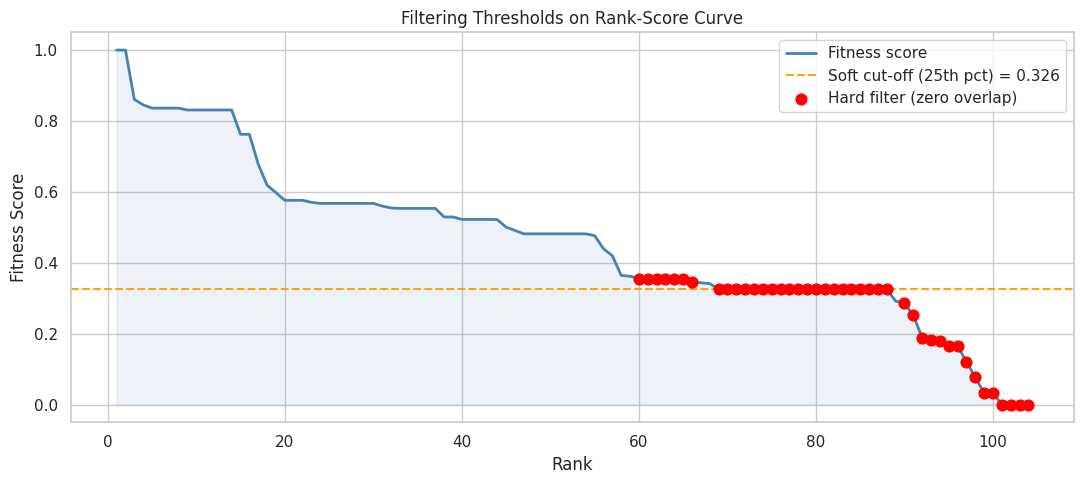

After filtering: 61 candidates remain from 104


In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df['rank'], df['fit'], color='steelblue', linewidth=2, label='Fitness score')
ax.fill_between(df['rank'], df['fit'], alpha=0.1, color='steelblue')
ax.axhline(SOFT_THRESHOLD, color='orange', linestyle='--', linewidth=1.5,
           label=f'Soft cut-off (25th pct) = {SOFT_THRESHOLD:.3f}')
ax.scatter(df[hard_mask]['rank'], df[hard_mask]['fit'], color='red', zorder=5, s=60,
           label='Hard filter (zero overlap)')
ax.set_xlabel('Rank'); ax.set_ylabel('Fitness Score')
ax.set_title('Filtering Thresholds on Rank-Score Curve')
ax.legend(); plt.tight_layout(); plt.show()
print(f'After filtering: {(~hard_mask & ~soft_mask).sum()} candidates remain from {len(df)}')

## 6 - Cut-Off Point: Generalizable Threshold

In [19]:
fits        = df['fit'].values
sorted_fits = np.sort(fits)[::-1]

# Method 1: Elbow (largest change in second derivative)
second_deriv = np.diff(np.diff(sorted_fits))
elbow_rank   = int(np.argmax(np.abs(second_deriv))) + 2
elbow_score  = sorted_fits[elbow_rank - 1]

# Method 2: Histogram valley
hist, edges  = np.histogram(sorted_fits, bins=15)
valley_bin   = int(np.argmin(hist[3:10])) + 3
valley_score = float(edges[valley_bin + 1])

# Method 3: 30th percentile (recommended - role-agnostic)
p30_score    = float(np.percentile(fits, 30))

print('Cut-off Comparison:')
print(f'  Elbow method      : rank={elbow_rank}, fit>={elbow_score:.4f}  -> {(fits>=elbow_score).sum()} candidates')
print(f'  Histogram valley  : fit>={valley_score:.4f}              -> {(fits>=valley_score).sum()} candidates')
print(f'  30th percentile   : fit>={p30_score:.4f}              -> {(fits>=p30_score).sum()} candidates')
print(f'\nRecommendation: 30th percentile is most role-agnostic.')
print(f'Default CUTOFF = {p30_score:.4f}. Tighten after several starring rounds.')

Cut-off Comparison:
  Elbow method      : rank=2, fit>=1.0000  -> 2 candidates
  Histogram valley  : fit>=0.2667              -> 90 candidates
  30th percentile   : fit>=0.3258              -> 88 candidates

Recommendation: 30th percentile is most role-agnostic.
Default CUTOFF = 0.3258. Tighten after several starring rounds.


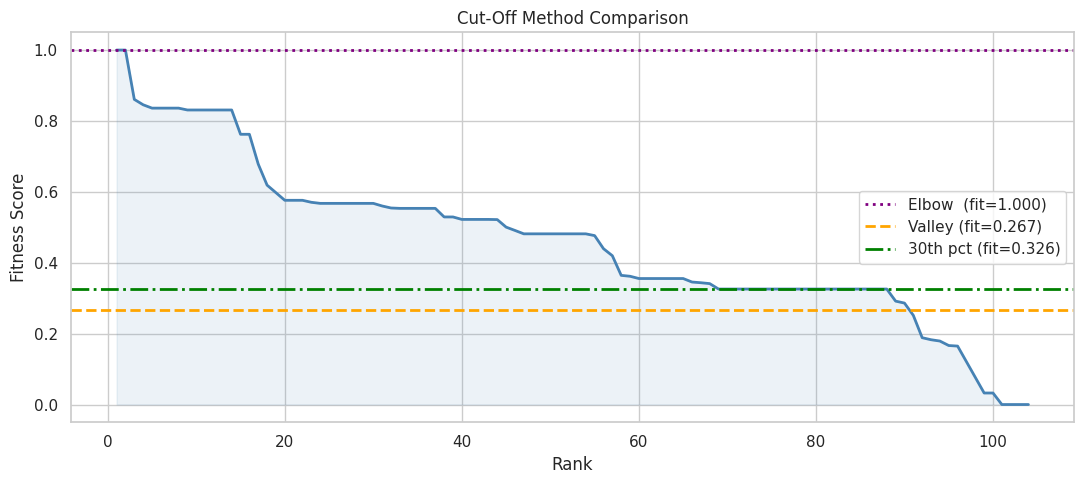

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(1, len(sorted_fits)+1), sorted_fits, color='steelblue', linewidth=2)
ax.fill_between(range(1, len(sorted_fits)+1), sorted_fits, alpha=0.1, color='steelblue')
ax.axhline(elbow_score,  color='purple', linestyle=':',  lw=2, label=f'Elbow  (fit={elbow_score:.3f})')
ax.axhline(valley_score, color='orange', linestyle='--', lw=2, label=f'Valley (fit={valley_score:.3f})')
ax.axhline(p30_score,    color='green',  linestyle='-.', lw=2, label=f'30th pct (fit={p30_score:.3f})')
ax.set_xlabel('Rank'); ax.set_ylabel('Fitness Score')
ax.set_title('Cut-Off Method Comparison')
ax.legend(); plt.tight_layout(); plt.show()

## 7 - Bias Mitigation Strategies

In [21]:
# Strategy 1: Location diversity
print('Location distribution in top-30 vs all:')
top30 = df[df['rank'] <= 30]
loc_top = top30['location'].value_counts().rename('top30')
loc_all = df['location'].value_counts().rename('all')
print(pd.concat([loc_top, loc_all], axis=1).head(10).fillna(0).astype(int).to_string())

Location distribution in top-30 vs all:
                                     top30  all
location                                       
Raleigh-Durham, North Carolina Area      8    8
Kanada                                   7   12
Greater Philadelphia Area                4    5
Houston, Texas Area                      3    8
Amerika Birleşik Devletleri              2    2
Chicago, Illinois                        2    2
Kokomo, Indiana Area                     1    1
Las Vegas, Nevada Area                   1    1
San Jose, California                     1    1
Greater New York City Area               1    7


In [22]:
# Strategy 2: Hidden gems (high cosine sim but low connections)
gems = df[
    (df['cosine_score'] >= df['cosine_score'].quantile(0.60)) &
    (df['conn_num'] < 50)
].sort_values('cosine_score', ascending=False)

print('High-similarity candidates with <50 connections (potential hidden gems):')
display(gems[['rank','id','job_title','connection','cosine_score','fit']]
        .head(10).style
        .format({'cosine_score': '{:.3f}', 'fit': '{:.3f}'})
        .background_gradient(subset=['cosine_score'], cmap='YlGn'))

High-similarity candidates with <50 connections (potential hidden gems):


,rank,id,job_title,connection,cosine_score,fit
3,4,99,Seeking Human Resources Position,48,0.446,0.846
8,9,3,Aspiring Human Resources Professional,44,0.440,0.831
9,10,21,Aspiring Human Resources Professional,44,0.440,0.831
10,11,46,Aspiring Human Resources Professional,44,0.440,0.831
11,12,58,Aspiring Human Resources Professional,44,0.440,0.831
12,13,17,Aspiring Human Resources Professional,44,0.440,0.831
13,14,33,Aspiring Human Resources Professional,44,0.440,0.831
32,33,36,Aspiring Human Resources Specialist,1,0.382,0.553
36,37,60,Aspiring Human Resources Specialist,1,0.382,0.553
33,34,24,Aspiring Human Resources Specialist,1,0.382,0.553


In [23]:
# Strategy 3: Negative starring (penalise similar-to-rejected candidates)
def penalize(df, candidate_vecs_dense, id_to_vec_idx,
             penalized_ids, starred_ids, alpha=0.55, beta=0.45, gamma=0.20):
    """
    score = alpha*fit + beta*sim_to_starred - gamma*sim_to_penalized
    """
    def avg_sim(anchor_ids):
        vecs = candidate_vecs_dense[[id_to_vec_idx[int(i)] for i in anchor_ids]].mean(axis=0, keepdims=True)
        sims = cosine_similarity(vecs, candidate_vecs_dense).flatten()
        return (sims - sims.min()) / (sims.max() - sims.min() + 1e-9)

    pos_norm = avg_sim(starred_ids)
    neg_norm = avg_sim(penalized_ids)

    df2 = df.copy()
    df2['pos_sim'] = df2['id'].apply(lambda x: pos_norm[id_to_vec_idx[int(x)]])
    df2['neg_sim'] = df2['id'].apply(lambda x: neg_norm[id_to_vec_idx[int(x)]])
    df2['penalized_fit'] = alpha * df2['fit'] + beta * df2['pos_sim'] - gamma * df2['neg_sim']
    df2 = df2.sort_values('penalized_fit', ascending=False).reset_index(drop=True)
    df2['new_rank'] = df2.index + 1
    return df2

BAD_ID = 86  # IT programmer - clearly off-role
print(f"Penalising id={BAD_ID}: '{df[df['id']==BAD_ID]['job_title'].values[0]}'")
r_pen = penalize(df, candidate_vecs_dense, id_to_vec_idx,
                 penalized_ids=[BAD_ID], starred_ids=[STARRED_ID_1])
print('\nTop 10 with negative penalty applied:')
display(r_pen[['new_rank','id','job_title','connection','penalized_fit']]
        .head(10).style.format({'penalized_fit': '{:.4f}'})
        .background_gradient(subset=['penalized_fit'], cmap='YlGn'))

Penalising id=86: 'Information Systems Specialist and Programmer with a love for data and organization.'

Top 10 with negative penalty applied:


,new_rank,id,job_title,connection,penalized_fit
0,1,10,Seeking Human Resources HRIS and Generalist Positions,500+,0.9099
1,2,40,Seeking Human Resources HRIS and Generalist Positions,500+,0.9099
2,3,53,Seeking Human Resources HRIS and Generalist Positions,500+,0.9099
3,4,62,Seeking Human Resources HRIS and Generalist Positions,500+,0.9099
4,5,30,Seeking Human Resources Opportunities,390,0.6874
5,6,28,Seeking Human Resources Opportunities,390,0.6874
6,7,99,Seeking Human Resources Position,48,0.5978
7,8,97,Aspiring Human Resources Professional,71,0.5268
8,9,3,Aspiring Human Resources Professional,44,0.5104
9,10,21,Aspiring Human Resources Professional,44,0.5104


In [24]:
# Strategy 4: Diversity-aware re-ranking via MMR
# Maximal Marginal Relevance: at each step pick candidate that maximises
# (relevance - redundancy with already-selected set)

def mmr_rerank(df, candidate_vecs_dense, id_to_vec_idx, fit_col='fit', lmbda=0.7, top_k=20):
    """
    lmbda=1 -> pure relevance; lmbda=0 -> pure diversity
    """
    ids  = df['id'].tolist()
    fits = dict(zip(df['id'], df[fit_col]))
    vecs = {int(cid): candidate_vecs_dense[id_to_vec_idx[int(cid)]] for cid in ids}

    selected, remaining = [], list(ids)
    while remaining and len(selected) < top_k:
        if not selected:
            best = max(remaining, key=lambda x: fits[x])
        else:
            sel_mat = np.stack([vecs[int(s)] for s in selected])
            best = max(remaining, key=lambda cid:
                lmbda * fits[cid] -
                (1 - lmbda) * cosine_similarity(vecs[int(cid)].reshape(1,-1), sel_mat).max()
            )
        selected.append(best)
        remaining.remove(best)

    mmr_df = df.set_index('id').loc[selected].reset_index()
    mmr_df['mmr_rank'] = range(1, len(mmr_df)+1)
    return mmr_df

mmr = mmr_rerank(df, candidate_vecs_dense, id_to_vec_idx, lmbda=0.7, top_k=15)
print('Top 15 with MMR diversity-aware re-ranking (lambda=0.7):')
display(mmr[['mmr_rank','id','job_title','connection','fit']]
        .style.format({'fit': '{:.4f}'})
        .background_gradient(subset=['fit'], cmap='YlGn'))

Top 15 with MMR diversity-aware re-ranking (lambda=0.7):


,mmr_rank,id,job_title,connection,fit
0,1,28,Seeking Human Resources Opportunities,390,1.0000
1,2,97,Aspiring Human Resources Professional,71,0.8608
2,3,62,Seeking Human Resources HRIS and Generalist Positions,500+,0.8362
3,4,99,Seeking Human Resources Position,48,0.8456
4,5,27,Aspiring Human Resources Management student seeking an internship,500+,0.7624
5,6,30,Seeking Human Resources Opportunities,390,1.0000
6,7,75,"Nortia Staffing is seeking Human Resources, Payroll & Administrative Professionals!! (408) 709-2621",500+,0.6189
7,8,68,Human Resources Specialist at Luxottica,500+,0.5705
8,9,71,"Human Resources Generalist at ScottMadden, Inc.",500+,0.5761
9,10,13,Human Resources Coordinator at InterContinental Buckhead Atlanta,500+,0.5222


## 8 - Interactive Starring Widget (Colab)

In [25]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print('ipywidgets not available')

if HAS_WIDGETS:
    starred_state = []
    out = widgets.Output()

    def refresh(frame):
        with out:
            clear_output(wait=True)
            sc = 'reranked_fit' if 'reranked_fit' in frame.columns else 'fit'
            rk = 'new_rank'     if 'new_rank'     in frame.columns else 'rank'
            display(frame[[rk,'id','job_title','connection',sc]]
                    .head(20).style.format({sc: '{:.4f}'})
                    .background_gradient(subset=[sc], cmap='YlGn')
                    .set_caption(f'Starred: {starred_state or "none"}'))

    id_dd   = widgets.Dropdown(
        options=[(f"id={int(r['id'])} | {r['job_title'][:65]}", int(r['id'])) for _, r in df.iterrows()],
        description='Star:', layout=widgets.Layout(width='720px'))
    s_btn   = widgets.Button(description='Star',  button_style='warning')
    r_btn   = widgets.Button(description='Reset', button_style='info')

    def on_star(_):
        sid = id_dd.value
        if sid not in starred_state: starred_state.append(sid)
        refresh(rerank(df, candidate_vecs_dense, id_to_vec_idx, starred_state))

    def on_reset(_):
        starred_state.clear(); refresh(df)

    s_btn.on_click(on_star); r_btn.on_click(on_reset)
    refresh(df)
    display(widgets.VBox([widgets.HBox([id_dd, s_btn, r_btn]), out]))

## 9 - Summary & Recommendations

### Pipeline at a glance
| Stage | Method | Key parameter |
|---|---|---|
| Feature extraction | TF-IDF (1+2-gram, sublinear TF) | ngram_range=(1,2) |
| Initial score | Weighted cosine + log-connections + keyword boost | W = [0.70, 0.20, 0.10] |
| Re-ranking | Blend with averaged starred vector as ideal | alpha=0.55, beta=0.45 |
| Negative examples | Penalise similarity to rejected candidates | gamma=0.20 |
| Diversity | Maximal Marginal Relevance | lambda=0.70 |
| Hard filter | Zero cosine similarity to query | removes ~4 candidates |
| Cut-off | 30th percentile of fitness scores | ~0.33 for this dataset |

### Why re-ranking improves with each starring
Each starred candidate refines the **ideal profile vector** (average TF-IDF of all starred). As more signal accumulates the ideal profile converges toward true recruiter preference, surfacing candidates that match the implicit human standard rather than just keyword frequency.

### Cut-off recommendation
The **30th percentile** threshold is role-agnostic: calculated fresh from each role's score distribution. It preserves the top 70% including borderline high-potential candidates. Tighten to the 50th percentile only after several starring rounds when the ideal profile has stabilised.

### Ideas to reduce human bias
1. **Blind titles** - strip seniority words (Senior, Jr.) before scoring; evaluate on skill signals only.
2. **Location-diverse shortlists** - cap max share per geography in the presented top-N.
3. **Negative starring** - disqualify signal patterns, not just individuals, correcting drift toward any single profile type.
4. **MMR diversity** - present a diverse shortlist even at a slight relevance cost.
5. **Audit starred history** - periodically check whether all starred candidates share a non-relevant attribute (same city, same school) and inject counter-examples.
6. **Richer embeddings** - as resume/skills data becomes available, replace title-only TF-IDF with sentence embeddings (all-MiniLM via sentence-transformers) for deeper semantic understanding.

In [26]:
out_path = 'ranked_candidates_final.csv'
df[['rank','id','job_title','location','connection','cosine_score','conn_score','kw_boost','fit']]\
  .to_csv(out_path, index=False)
print(f'Saved -> {out_path}')

# Uncomment to download in Colab:
# from google.colab import files; files.download(out_path)

Saved -> ranked_candidates_final.csv
